# Chapter 15 laboratory: learn the residual left by belief propagation

This notebook tests the reference--correction principle in a simple supervised setting.

For each small loopy Ising model we can compute the exact partition function $Z$ by enumeration and the Bethe/BP estimate $Z^{\rm BP}$ from a converged BP fixed point. We compare two learning tasks:

1. **direct:** predict $\log Z$ from the raw model parameters;
2. **reference--correction:** compute $\log Z^{\rm BP}$ classically and learn only

$$
\Delta_{\rm BP}=\log Z-\log Z^{\rm BP}.
$$

The second construction does not guarantee that the residual is easier. That is an empirical question. Its conceptual advantage is that the learned object has a precise meaning and the structured reference is retained explicitly.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

FIGDIR = Path("figs")
FIGDIR.mkdir(exist_ok=True)
plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
    "figure.titlesize": 19,
})
rng = np.random.default_rng(11)

L=3
nodes=list(range(L*L))
edges=[]
for r in range(L):
    for c in range(L):
        i=r*L+c
        if c+1<L: edges.append((i,i+1))
        if r+1<L: edges.append((i,i+L))
directed=[(i,j) for i,j in edges for (i,j) in [(i,j),(j,i)]]
dir_index={e:k for k,e in enumerate(directed)}
neigh={i:[] for i in nodes}
for i,j in edges:
    neigh[i].append(j); neigh[j].append(i)

def bp_fixed_point(h,Jvals,init=None,tol=1e-9,maxiter=1000,damping=0.55):
    J={tuple(sorted(e)):v for e,v in zip(edges,Jvals)}
    u=np.zeros(len(directed)) if init is None else np.array(init,dtype=float).copy()
    for it in range(maxiter):
        new=np.empty_like(u)
        for q,(i,j) in enumerate(directed):
            H=h[i] + sum(u[dir_index[(k,i)]] for k in neigh[i] if k!=j)
            z=np.tanh(J[tuple(sorted((i,j)))])*np.tanh(H)
            z=np.clip(z,-1+1e-13,1-1e-13)
            new[q]=np.arctanh(z)
        upd=(1-damping)*u+damping*new
        res=np.max(np.abs(upd-u))
        u=upd
        if res<tol:
            return u,it+1,res
    return u,maxiter,res

def bp_beliefs_and_logz(h,Jvals,u):
    J={tuple(sorted(e)):v for e,v in zip(edges,Jvals)}
    bi={}
    for i in nodes:
        H=h[i]+sum(u[dir_index[(k,i)]] for k in neigh[i])
        pplus=1/(1+np.exp(-2*H))
        bi[i]=np.array([1-pplus,pplus])  # states -1,+1
    bij={}
    states=np.array([-1,1])
    for e,(i,j) in enumerate(edges):
        Hij=h[i]+sum(u[dir_index[(k,i)]] for k in neigh[i] if k!=j)
        Hji=h[j]+sum(u[dir_index[(k,j)]] for k in neigh[j] if k!=i)
        W=np.exp(Jvals[e]*np.outer(states,states)+Hij*states[:,None]+Hji*states[None,:])
        bij[(i,j)]=W/W.sum()
    # Bethe free energy using unary and edge factors
    F=0.0
    for e,(i,j) in enumerate(edges):
        b=bij[(i,j)]
        logpsi=Jvals[e]*np.outer(states,states)
        F += np.sum(b*(np.log(b+1e-300)-logpsi))
    for i in nodes:
        b=bi[i]
        logpsi=h[i]*states
        # Pairwise Bethe free energy: singleton entropy has coefficient
        # (1-d_i), whereas the unary energy appears exactly once.
        F += (1-len(neigh[i]))*np.sum(b*np.log(b+1e-300))
        F -= np.sum(b*logpsi)
    return bi,bij,-F

SPINS=np.array(np.meshgrid(*([[-1,1]]*len(nodes)), indexing='ij')).reshape(len(nodes),-1).T

def exact_logz(h,Jvals):
    X=SPINS
    energy=X@h
    for val,(i,j) in zip(Jvals,edges): energy += val*X[:,i]*X[:,j]
    m=energy.max()
    return m+np.log(np.exp(energy-m).sum())

def make_instances(n,jlo,jhi,hscale=0.20):
    H=rng.normal(0,hscale,size=(n,len(nodes)))
    J=rng.uniform(jlo,jhi,size=(n,len(edges)))
    return H,J


## 1. Build exact labels and BP features

The exact enumeration is inexpensive on a $3\times3$ grid and therefore gives a clean benchmark. In addition to raw fields and couplings, the residual predictor receives BP-derived magnetizations, pair correlations, and $\log Z^{\rm BP}$.

In [2]:
def dataset(n,jlo,jhi):
    H,J=make_instances(n,jlo,jhi)
    raw=[]; structured=[]; y=[]; res=[]; bpvals=[]
    states=np.array([-1,1])
    for h,j in zip(H,J):
        u,_,_=bp_fixed_point(h,j)
        bi,bij,lzbp=bp_beliefs_and_logz(h,j,u)
        lz=exact_logz(h,j)
        mags=np.array([bi[i][1]-bi[i][0] for i in nodes])
        cors=np.array([sum(bij[e][a,b]*states[a]*states[b] for a in range(2) for b in range(2)) for e in edges])
        r=np.hstack([h,j])
        raw.append(r)
        structured.append(np.hstack([r,[lzbp],mags,cors]))
        y.append(lz); res.append(lz-lzbp); bpvals.append(lzbp)
    return np.array(raw),np.array(structured),np.array(y),np.array(res),np.array(bpvals)

Xr_tr,Xs_tr,y_tr,r_tr,bp_tr=dataset(420,0.05,0.46)
Xr_te,Xs_te,y_te,r_te,bp_te=dataset(140,0.05,0.46)
Xr_ood,Xs_ood,y_ood,r_ood,bp_ood=dataset(140,0.46,0.72)
print("BP MAE test:",mean_absolute_error(y_te,bp_te))
print("BP MAE stronger-coupling transfer:",mean_absolute_error(y_ood,bp_ood))

BP MAE test: 0.012782248944635801
BP MAE stronger-coupling transfer: 0.2669216103974691


In [3]:
direct=make_pipeline(StandardScaler(),MLPRegressor(hidden_layer_sizes=(64,64),activation="tanh",max_iter=320,random_state=2,early_stopping=True))
resid=make_pipeline(StandardScaler(),MLPRegressor(hidden_layer_sizes=(64,64),activation="tanh",max_iter=320,random_state=3,early_stopping=True))
direct.fit(Xr_tr,y_tr)
resid.fit(Xs_tr,r_tr)

pred_direct_te=direct.predict(Xr_te)
pred_resid_te=bp_te+resid.predict(Xs_te)
pred_direct_ood=direct.predict(Xr_ood)
pred_resid_ood=bp_ood+resid.predict(Xs_ood)

for name,true,a,b,bp in [
    ("test",y_te,pred_direct_te,pred_resid_te,bp_te),
    ("stronger J",y_ood,pred_direct_ood,pred_resid_ood,bp_ood)]:
    print(name)
    print("  BP MAE      ",mean_absolute_error(true,bp))
    print("  direct NN   ",mean_absolute_error(true,a))
    print("  BP+residual ",mean_absolute_error(true,b))

test
  BP MAE       0.012782248944635801
  direct NN    0.3770600764185415
  BP+residual  0.08145134850905415
stronger J
  BP MAE       0.2669216103974691
  direct NN    2.532877919632521
  BP+residual  0.280988793446946


/opt/pyvenv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (320) reached and the optimization hasn't converged yet.
  warnings.warn(


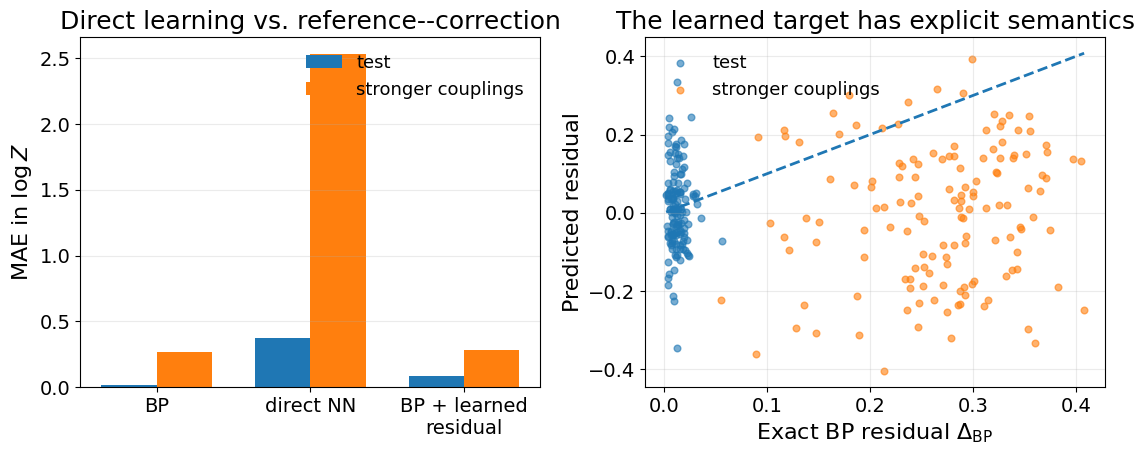

In [4]:
fig,axes=plt.subplots(1,2,figsize=(11.4,4.8))
methods=["BP","direct NN","BP + learned\nresidual"]
mae_test=[mean_absolute_error(y_te,bp_te),mean_absolute_error(y_te,pred_direct_te),mean_absolute_error(y_te,pred_resid_te)]
mae_ood=[mean_absolute_error(y_ood,bp_ood),mean_absolute_error(y_ood,pred_direct_ood),mean_absolute_error(y_ood,pred_resid_ood)]
x=np.arange(3); w=0.36
axes[0].bar(x-w/2,mae_test,w,label="test")
axes[0].bar(x+w/2,mae_ood,w,label="stronger couplings")
axes[0].set_xticks(x,methods)
axes[0].set_ylabel("MAE in $\\log Z$")
axes[0].set_title("Direct learning vs. reference--correction")
axes[0].legend(frameon=False)
axes[0].grid(axis="y",alpha=0.25)

axes[1].scatter(r_te,resid.predict(Xs_te),s=23,alpha=0.6,label="test")
axes[1].scatter(r_ood,resid.predict(Xs_ood),s=23,alpha=0.6,label="stronger couplings")
lims=[min(r_ood.min(),r_te.min()),max(r_ood.max(),r_te.max())]
axes[1].plot(lims,lims,linestyle="--",linewidth=2)
axes[1].set_xlabel("Exact BP residual $\\Delta_{\\rm BP}$")
axes[1].set_ylabel("Predicted residual")
axes[1].set_title("The learned target has explicit semantics")
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGDIR/"ch15_02_residual_vs_direct.pdf",bbox_inches="tight")
fig.savefig(FIGDIR/"ch15_02_residual_vs_direct.png",dpi=220,bbox_inches="tight")
plt.show()

## Interpretation

The outcome should be read comparatively, not doctrinally. A structured residual is attractive because it is tied to a known approximation and can often be bounded or further corrected, but it is not guaranteed to be statistically simpler than the full target for every model family.

The experiment also suggests a hierarchy for later work:

$$
\text{BP reference}
\rightarrow
\text{explicit short-loop correction}
\rightarrow
\text{learned remaining residual}.
$$

The more of the correction that is handled analytically, the narrower the task left to the neural surrogate.

## Exercises and challenges

1. Add short-cycle counts and local frustration indicators to the residual predictor. Which features improve transfer most?
2. Replace the BP reference by a mean-field reference and compare residual learnability.
3. Train one model on the direct target and residual simultaneously with a shared representation. Does multi-task training improve either one?
4. **Challenge:** after implementing fractional BP, replace the high-dimensional residual target by the scalar exact parameter $\lambda_*$. Compare sample complexity and transfer.